In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
import pylab
import warnings # Used to supressed the warnings
warnings.filterwarnings('ignore')

In [256]:
data = pd.read_csv("../../data/processed/after_visualize.csv")
data.drop("Unnamed: 0",inplace=True,axis=1)

In [257]:
data.columns

Index(['Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [258]:
cat_col = data.select_dtypes(include=['object']).columns.to_list()
cat_col

['Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'OverTime',
 'Attrition']

In [259]:
for i in cat_col:
    print(i," : ", data[i].unique())

Gender  :  ['Male' 'Female']
EducationBackground  :  ['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']
MaritalStatus  :  ['Single' 'Married' 'Divorced']
EmpDepartment  :  ['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']
EmpJobRole  :  ['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']
BusinessTravelFrequency  :  ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
OverTime  :  ['No' 'Yes']
Attrition  :  ['No' 'Yes']


In [260]:
# data.drop(['MaritalStatus','Attrition'],axis=1,inplace=True)

In [261]:
print(data['Gender'].value_counts())
print(data['OverTime'].value_counts())

Gender
Male      725
Female    475
Name: count, dtype: int64
OverTime
No     847
Yes    353
Name: count, dtype: int64


In [262]:
# # Binary encoding

# data['OverTime'] = data['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

# data['Gender'] = data['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# # 'MaritalStatus' in data.columns  --> irrelavent feature


# # One-hot encoding for nominal
# data = pd.get_dummies(
#     data,
#     columns=['EmpDepartment', 'EmpJobRole', 'EducationBackground', 'BusinessTravelFrequency'],
#     drop_first=True
# )


In [263]:
# data.head()

# Manual Encoding

## Gender

In [264]:
data.Gender.value_counts()

Gender
Male      725
Female    475
Name: count, dtype: int64

In [265]:
data.Gender = data.Gender.map({'Male':1,'Female':0})



## Education Background

In [266]:
data.EducationBackground.value_counts()

EducationBackground
Life Sciences       492
Medical             384
Marketing           137
Technical Degree    100
Other                66
Human Resources      21
Name: count, dtype: int64

In [267]:
data.loc[data['EducationBackground']=='Life Sciences','EducationBackground']  =5
data.loc[data['EducationBackground']=='Medical','EducationBackground']        =4
data.loc[data['EducationBackground']=='Marketing','EducationBackground']      =3
data.loc[data['EducationBackground']=='Technical Degree','EducationBackground']=2
data.loc[data['EducationBackground']=='Other','EducationBackground']          =1
data.loc[data['EducationBackground']=='Human Resources','EducationBackground']=0


# checking encoding
data.EducationBackground.value_counts()


EducationBackground
5    492
4    384
3    137
2    100
1     66
0     21
Name: count, dtype: int64

## Marital Status

In [268]:
data.MaritalStatus.value_counts()

MaritalStatus
Married     548
Single      384
Divorced    268
Name: count, dtype: int64

In [269]:
data.MaritalStatus = data.MaritalStatus.map({'Married':2,'Single':1,'Divorced':0})

## Employee Department

In [270]:
# Get the value counts of employee department 
data.EmpDepartment.value_counts()

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [271]:
# Use Frequency encoding
data.loc[data['EmpDepartment']=='Sales','EmpDepartment']=5
data.loc[data['EmpDepartment']=='Development','EmpDepartment']=4
data.loc[data['EmpDepartment']=='Research & Development','EmpDepartment']=3
data.loc[data['EmpDepartment']=='Human Resources','EmpDepartment']=2
data.loc[data['EmpDepartment']=='Finance','EmpDepartment']=1
data.loc[data['EmpDepartment']=='Data Science','EmpDepartment']=0

In [272]:
data.EmpDepartment.value_counts()


EmpDepartment
5    373
4    361
3    343
2     54
1     49
0     20
Name: count, dtype: int64

## Employee Job Role

In [273]:
# Getting the value counts of EmpJobRole
data.EmpJobRole.value_counts()

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
Human Resources               45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
Name: count, dtype: int64

In [274]:
# Use frequency encoding because feature contain a lots of label
data.loc[data['EmpJobRole']=='Sales Executive','EmpJobRole']=18
data.loc[data['EmpJobRole']=='Developer','EmpJobRole']=17
data.loc[data['EmpJobRole']=='Manager R&D','EmpJobRole']=16
data.loc[data['EmpJobRole']=='Research Scientist','EmpJobRole']=15
data.loc[data['EmpJobRole']=='Sales Representative','EmpJobRole']=14
data.loc[data['EmpJobRole']=='Laboratory Technician','EmpJobRole']=13
data.loc[data['EmpJobRole']=='Senior Developer','EmpJobRole']=12
data.loc[data['EmpJobRole']=='Manager','EmpJobRole']=11
data.loc[data['EmpJobRole']=='Finance Manager','EmpJobRole']=10
data.loc[data['EmpJobRole']=='Human Resources','EmpJobRole']=9
data.loc[data['EmpJobRole']=='Technical Lead','EmpJobRole']=8
data.loc[data['EmpJobRole']=='Manufacturing Director','EmpJobRole']=7
data.loc[data['EmpJobRole']=='Healthcare Representative','EmpJobRole']=6
data.loc[data['EmpJobRole']=='Data Scientist','EmpJobRole']=5
data.loc[data['EmpJobRole']=='Research Director','EmpJobRole']=4
data.loc[data['EmpJobRole']=='Business Analyst','EmpJobRole']=3
data.loc[data['EmpJobRole']=='Senior Manager R&D','EmpJobRole']=2
data.loc[data['EmpJobRole']=='Delivery Manager','EmpJobRole']=1
data.loc[data['EmpJobRole']=='Technical Architect','EmpJobRole']=0


# checking
data.EmpJobRole.value_counts()

EmpJobRole
18    270
17    236
16     94
15     77
14     69
13     64
12     52
11     51
10     49
9      45
8      38
7      33
6      33
5      20
4      19
3      16
2      15
1      12
0       7
Name: count, dtype: int64

## Business Travel Frequency

In [275]:
# Get the value count of buisness travel frequency
data.BusinessTravelFrequency.value_counts()

BusinessTravelFrequency
Travel_Rarely        846
Travel_Frequently    222
Non-Travel           132
Name: count, dtype: int64

In [276]:
# Use mannual encoding Because feature contain minimum label
data.BusinessTravelFrequency = data.BusinessTravelFrequency.map({'Travel_Rarely':2,'Travel_Frequently':1,'Non-Travel':0})

# checking
data.BusinessTravelFrequency.value_counts()

BusinessTravelFrequency
2    846
1    222
0    132
Name: count, dtype: int64

## Overtime

In [277]:
# Get the value count of Overtime
data.OverTime.value_counts()

OverTime
No     847
Yes    353
Name: count, dtype: int64

In [278]:
data.OverTime = data.OverTime.map({'No':1,'Yes':0})

# checking
data.OverTime.value_counts()

OverTime
1    847
0    353
Name: count, dtype: int64

## Skipping Attrition --> (Attrition was removed to prevent data leakage, as it represents a future outcome that occurs after performance evaluation and should not be used to predict employee performance.)

In [279]:
data.drop("Attrition",axis=1,inplace=True)

In [280]:
data.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
0,32,1,3,1,5,18,2,10,3,4,...,12,4,10,2,2,10,7,0,8,3
1,47,1,3,1,5,18,2,14,4,4,...,12,4,20,2,3,7,7,1,7,3
2,40,1,5,2,5,18,1,5,4,4,...,21,3,20,2,3,18,13,1,12,4
3,41,1,0,0,2,11,2,10,4,2,...,15,2,23,2,2,21,6,12,6,3
4,60,1,3,1,5,18,2,16,4,1,...,14,4,10,1,3,2,2,2,2,3


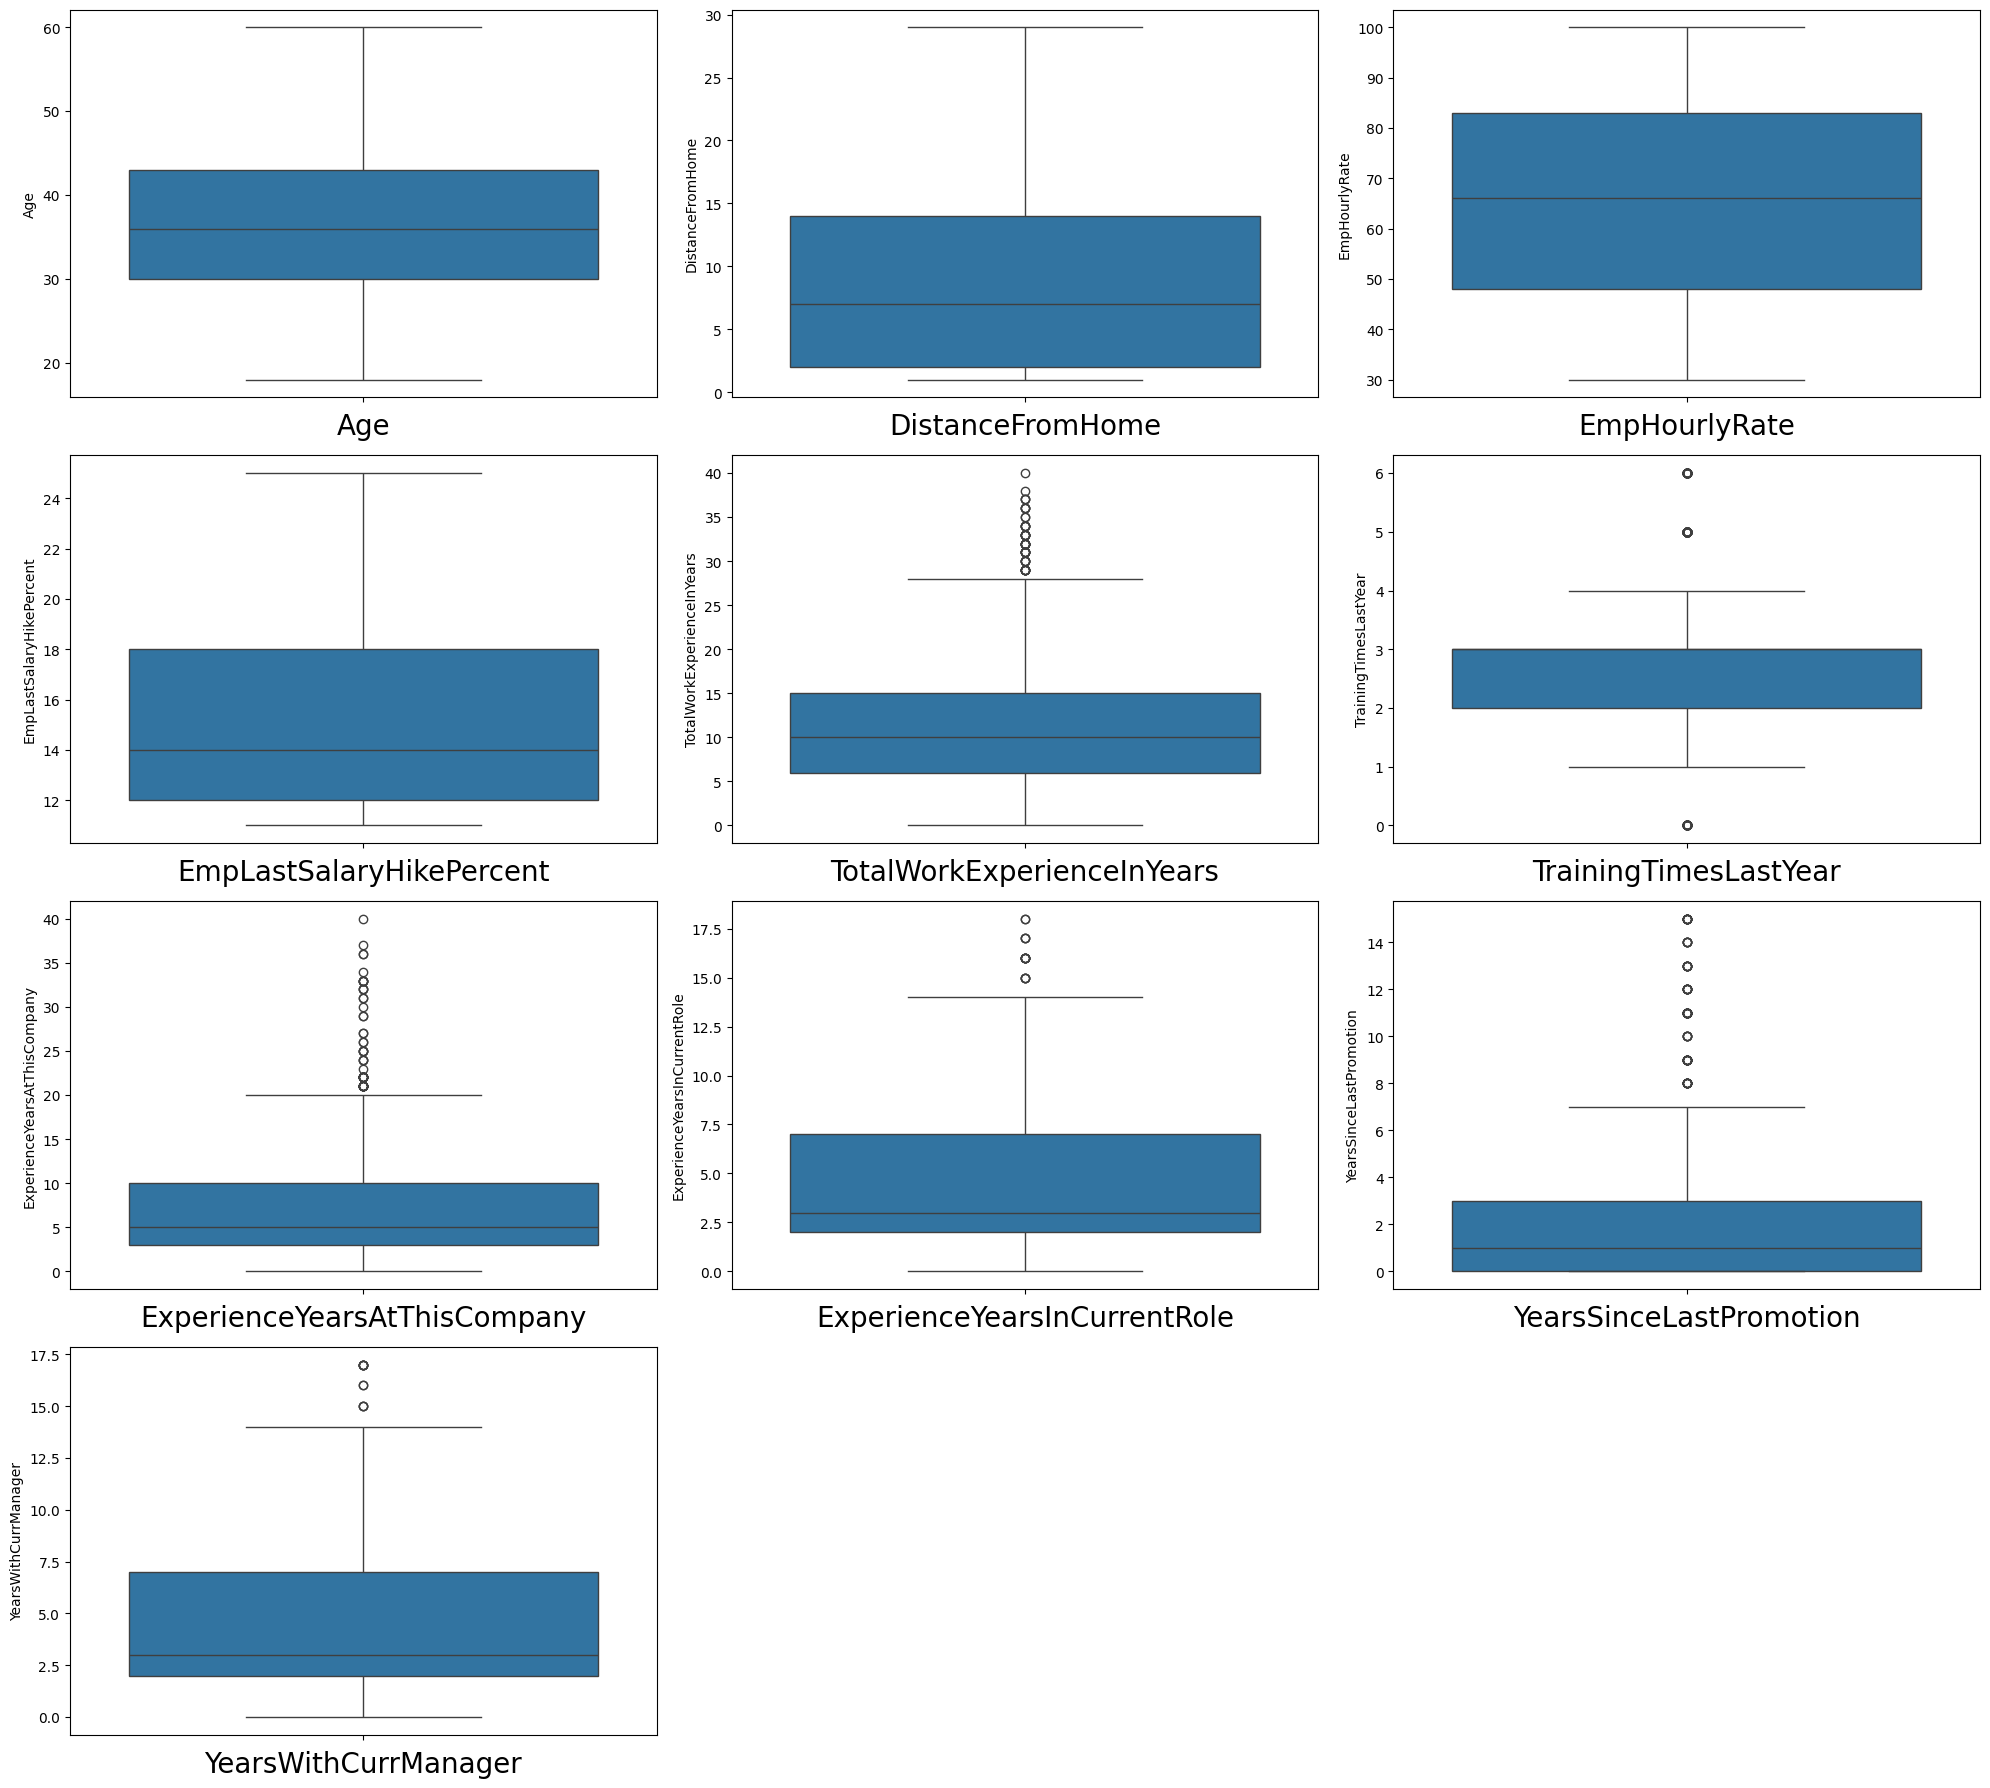

In [281]:
out = data[['Age','DistanceFromHome','EmpHourlyRate','EmpLastSalaryHikePercent',
                   'TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                   'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]
plt.figure(figsize=(20,18)) 
plotno = 1 
for column in out: 
    if plotno<=12: 
        plt.subplot(4,3,plotno) 
        sns.boxplot(out[column]) 
        plt.xlabel(column,fontsize=20)  
    plotno+=1 
plt.tight_layout()
plt.show() 

## IQR to Handle Outliers

### Total Work Experiance in year

In [282]:
Q1 = data['TotalWorkExperienceInYears'].quantile(0.25)
Q3 = data['TotalWorkExperienceInYears'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['TotalWorkExperienceInYears'] = data['TotalWorkExperienceInYears'].clip(lower, upper)


data.column

In [283]:
data.columns

Index(['Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating'],
      dtype='object')

### Training Times Last Year

In [284]:
Q1 = data['TrainingTimesLastYear'].quantile(0.25)
Q3 = data['TrainingTimesLastYear'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['TrainingTimesLastYear'] = data['TrainingTimesLastYear'].clip(lower, upper)

### Experience Years At This Company

In [285]:
Q1 = data['ExperienceYearsAtThisCompany'].quantile(0.25)
Q3 = data['ExperienceYearsAtThisCompany'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['ExperienceYearsAtThisCompany'] = data['ExperienceYearsAtThisCompany'].clip(lower, upper)

### Experience Years In Current Role

In [286]:


Q1 = data['ExperienceYearsInCurrentRole'].quantile(0.25)
Q3 = data['ExperienceYearsInCurrentRole'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['ExperienceYearsInCurrentRole'] = data['ExperienceYearsInCurrentRole'].clip(lower, upper)

### Years Since Last Promotion

In [287]:


Q1 = data['YearsSinceLastPromotion'].quantile(0.25)
Q3 = data['YearsSinceLastPromotion'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsSinceLastPromotion'] = data['YearsSinceLastPromotion'].clip(lower, upper)

### Years With Current Manager

In [288]:




Q1 = data['YearsWithCurrManager'].quantile(0.25)
Q3 = data['YearsWithCurrManager'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsWithCurrManager'] = data['YearsWithCurrManager'].clip(lower, upper)

## Checking The Outliers

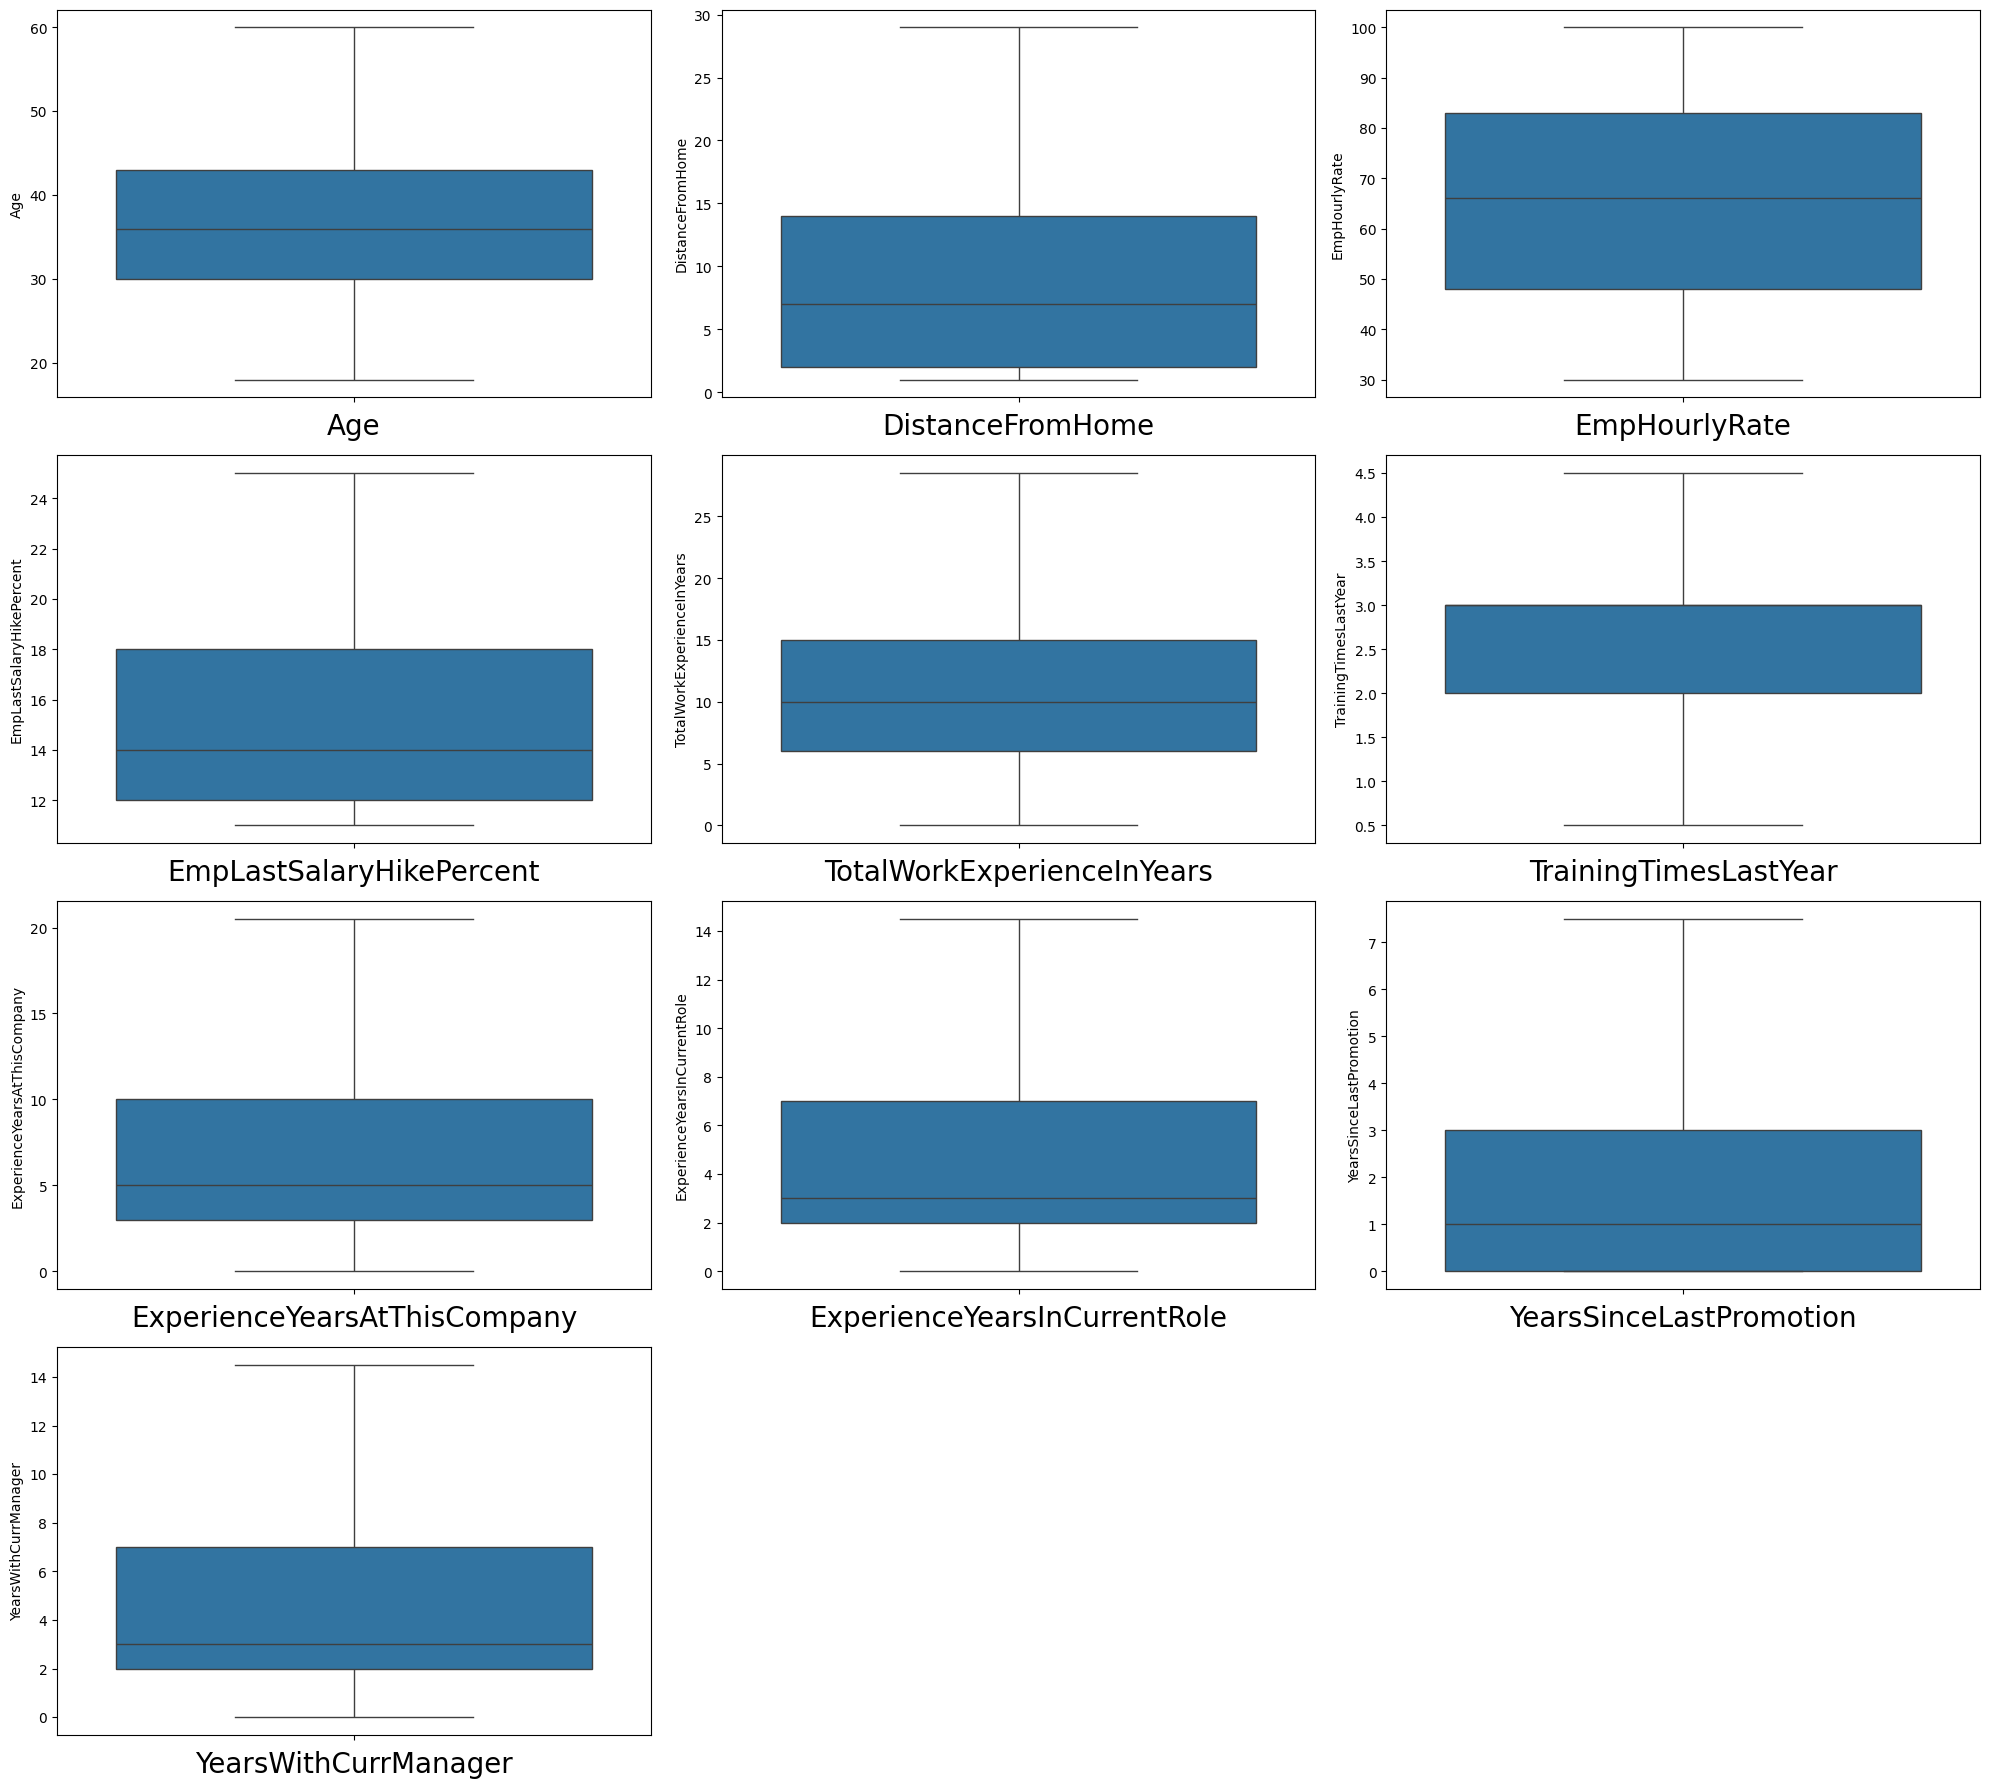

In [289]:
out = data[['Age','DistanceFromHome','EmpHourlyRate','EmpLastSalaryHikePercent',
                   'TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                   'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]
plt.figure(figsize=(20,18)) 
plotno = 1 
for column in out: 
    if plotno<=12: 
        plt.subplot(4,3,plotno) 
        sns.boxplot(out[column]) 
        plt.xlabel(column,fontsize=20)  
    plotno+=1 
plt.tight_layout()
plt.show() 

# Correlation

<Axes: >

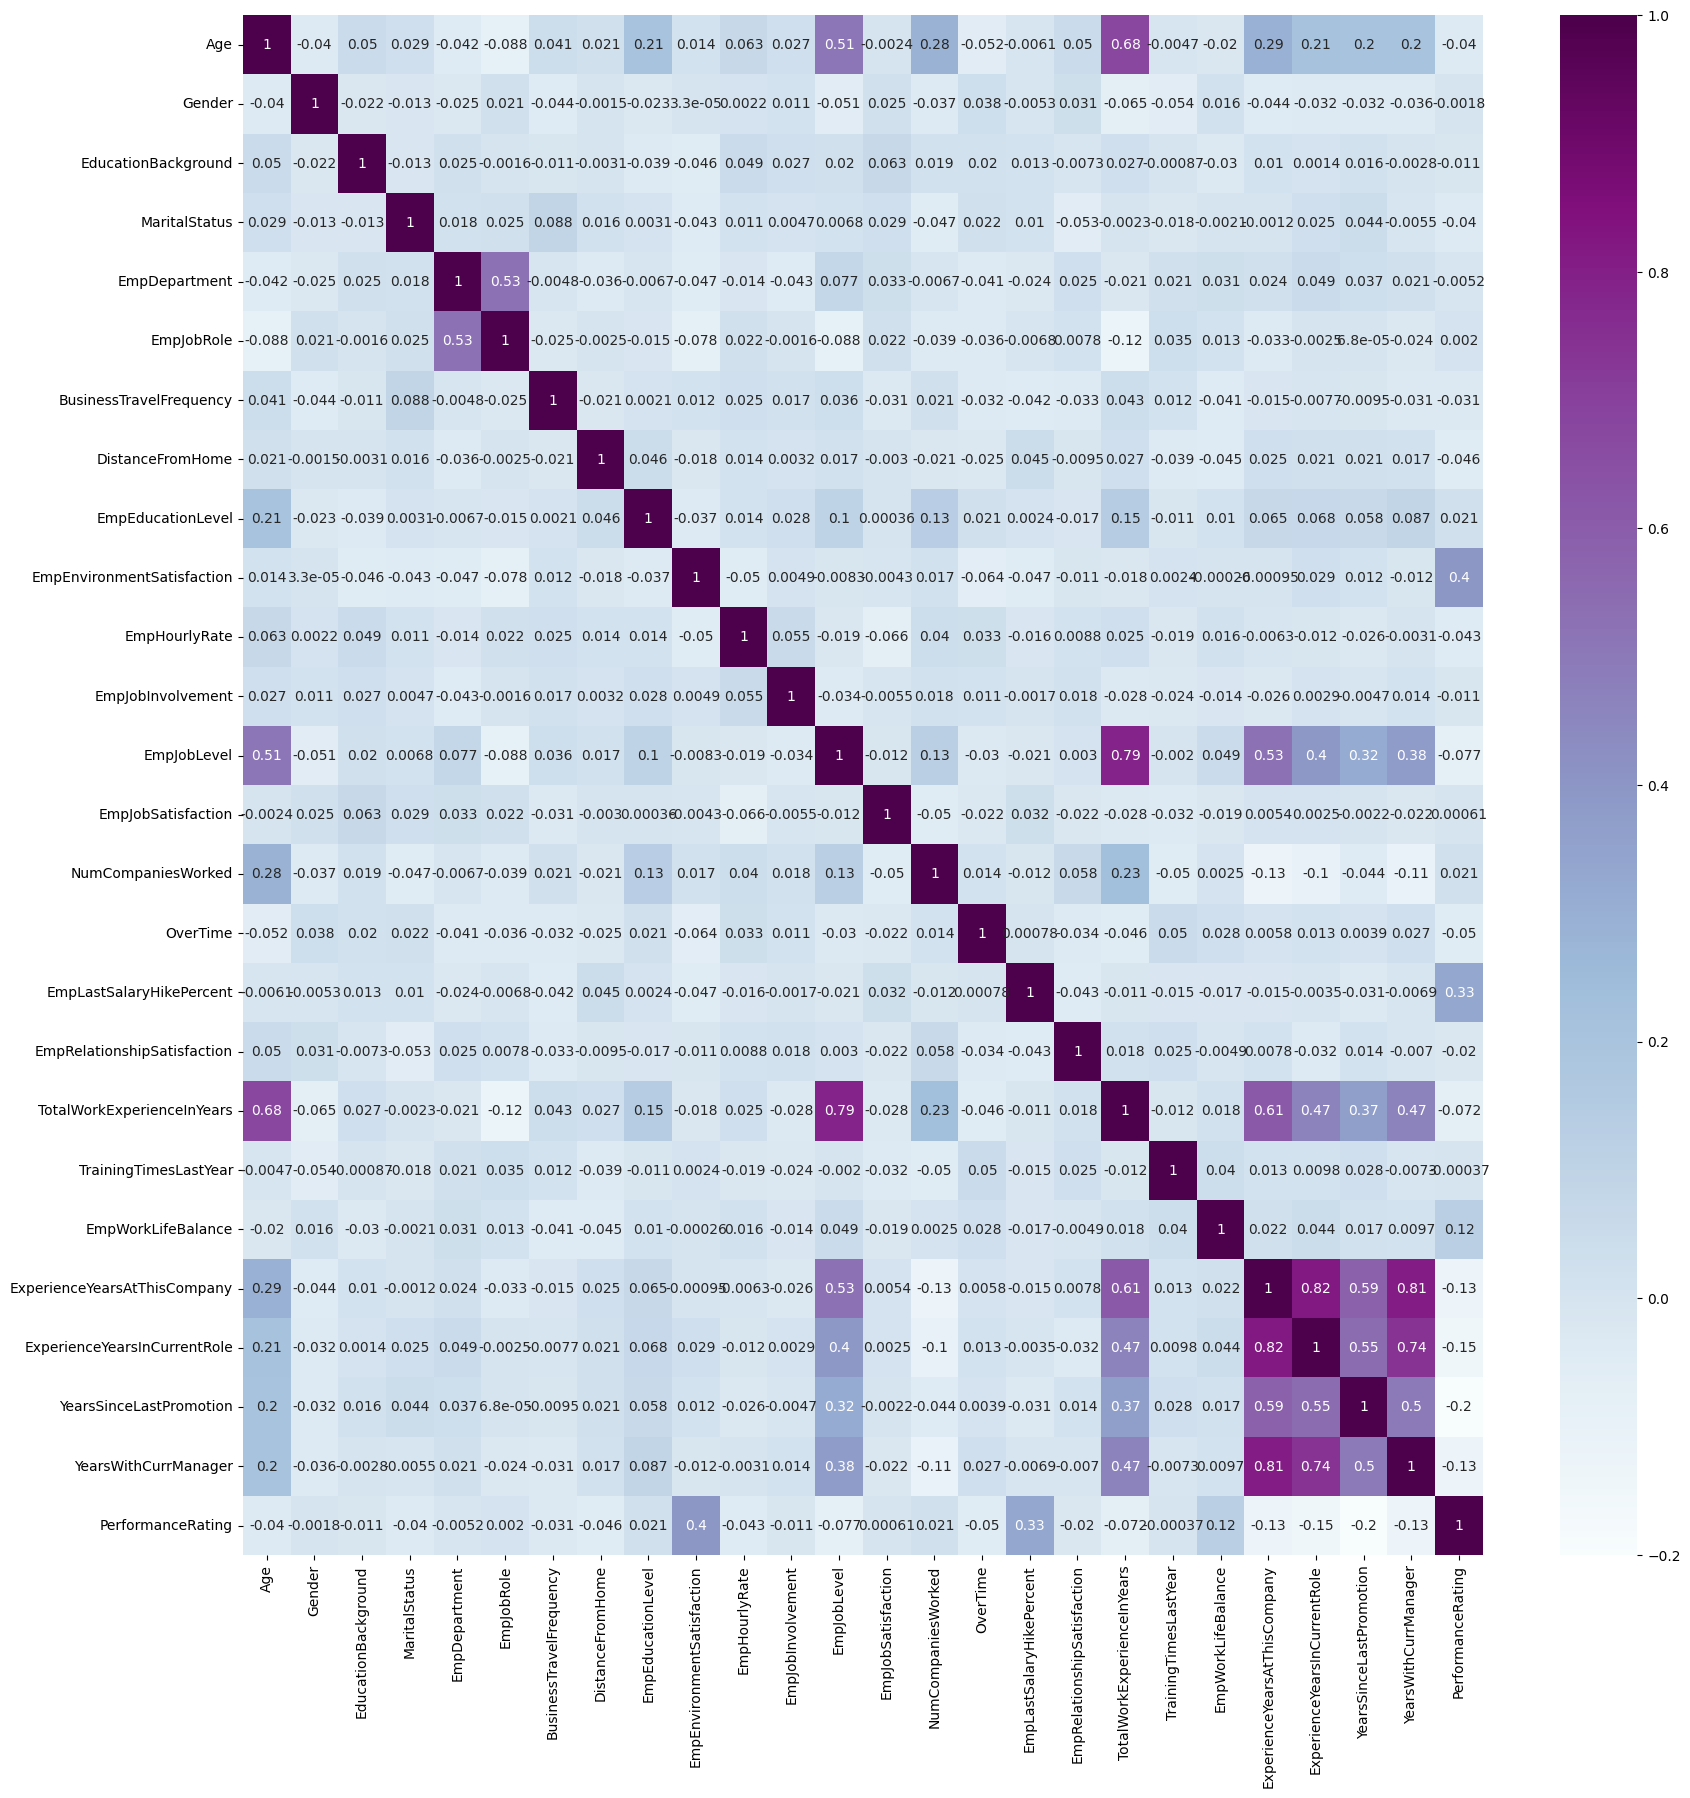

In [292]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(),annot=True,cmap="BuPu")

# Define X and y

In [293]:
X = data.drop('PerformanceRating', axis=1)
y = data['PerformanceRating']

In [294]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Decision Tree

In [295]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [296]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8958333333333334
              precision    recall  f1-score   support

           2       0.79      0.77      0.78        39
           3       0.93      0.94      0.93       175
           4       0.83      0.77      0.80        26

    accuracy                           0.90       240
   macro avg       0.85      0.83      0.84       240
weighted avg       0.89      0.90      0.89       240



# Random Forest (MAIN MODEL)

In [297]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)

In [300]:
print("Random Forest Accuracy:", accuracy_score(y_test, rfc_pred))
print(classification_report(y_test, rfc_pred))


Random Forest Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           2       0.91      0.82      0.86        39
           3       0.93      0.98      0.96       175
           4       1.00      0.77      0.87        26

    accuracy                           0.93       240
   macro avg       0.95      0.86      0.90       240
weighted avg       0.93      0.93      0.93       240



# Gradient Boosting

In [302]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train,y_train)

gbc_pred = gbc.predict(X_test)

print("GB Accurancy : ", accuracy_score(y_test,gbc_pred))

GB Accurancy :  0.9333333333333333


# Feature Importance

In [301]:
import pandas as pd

feature_importance = pd.Series(
    rfc.feature_importances_ , 
    index= X.columns , 
   ).sort_values(ascending=False)

feature_importance.head()

EmpLastSalaryHikePercent        0.209552
EmpEnvironmentSatisfaction      0.193599
YearsSinceLastPromotion         0.093872
ExperienceYearsInCurrentRole    0.042550
EmpHourlyRate                   0.041503
dtype: float64

# Random Forest was selected as the final model because it achieved the highest accuracy among the tested models.

In [303]:
data.to_csv("../../data/processed/Final_Data_for_Models.csv")